Step 03 - 2D Diffusion Equation

Here, the goal was to understand the concept of discretization of second order deriatives using the central difference scheme (a combination of forward and backward difference of the first derivative), also the use of the Taylor expansion series. The second order derivatives arises from the 2D diffusion equation.

In [6]:
# # importing a 3D viewer library
from mpl_toolkits.mplot3d import Axes3D

# importing neccesary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


# variables declaration
nx = 31 # number of grid points in x-direction
ny = 31 # number of grid points in y-direction
nt = 100 # number of time steps
nu = .05 # diffusion coefficient
dx = 2 / (nx - 1) # grid spacing in x-direction
dy = 2 / (ny - 1) # grid spacing in y-direction
sigma = .25 # CFL number
dt = sigma * dx * dy / nu # time step size

# initializing the grid points
x = np.linspace(0, 2, nx) # creating a grid in x-direction
y = np.linspace(0, 2, ny) # creating a grid in y-direction

# initializing the temporary and permanent arrays of u
u = np.ones((ny, nx)) # initializing the u-component array with ones
un = np.ones((ny, nx)) # initializing the temporary u-component array with ones


# assigining the initial conditions for u-component
u[int(.5 / dy):int(1 / dy + 1), int(.5 / dx):int(1 / dx + 1)] = 2 # setting the initial condition 

Text(0.5, 0.5, '$y$')

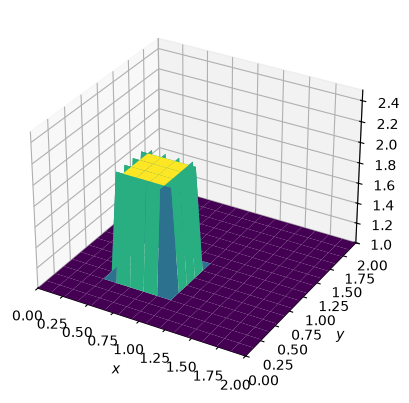

In [7]:
# testing the initial conditions by plotting the u
fig = plt.figure() # creating a figure
ax = fig.add_subplot(projection='3d') # creating a 3D axis
X, Y = np.meshgrid(x, y) # creating a meshgrid for x and
surf = ax.plot_surface(X, Y, u[:], cmap=cm.viridis, rstride=2, cstride=2) # plotting the surface for u-component

ax.set_xlim(0, 2) # setting the limits for x-axis
ax.set_ylim(0, 2) # setting the limits for y-axis
ax.set_zlim(1, 2.5) # setting the limits for z-axis

ax.set_xlabel('$x$') # setting the labels for the axes
ax.set_ylabel('$y$') # setting the labels for the axes

In [8]:
# putting the diffusion equation implementation in a function

def diffuse(nt):
    u[int(.5 / dy):int(1 / dy + 1), int(.5 / dx):int(1 / dx + 1)] = 2 # setting the initial condition

    for n in range(nt + 1):
        un = u.copy() # copying the values of u into un
        u[1:-1, 1:-1] = (un[1:-1, 1:-1] + nu * dt / dx ** 2 *
                         (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                         nu * dt / dy ** 2 *
                         (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])) # implementing the diffusion equation

        u[0, :] = 1 # setting the boundary conditions
        u[-1, :] = 1 # setting the boundary conditions
        u[:, 0] = 1 # setting the boundary conditions
        u[:, -1] = 1 # setting the boundary conditions
    
    # plotting the final results for u
    fig = plt.figure() # creating a figure
    ax = fig.add_subplot(projection='3d') # creating a 3D axis
    surf = ax.plot_surface(X, Y, u[:], cmap=cm.viridis, rstride=2, cstride=2) # plotting the surface for u-component
    ax.set_zlim(1, 2.5) # setting the limits for z-axis
    ax.set_xlabel('$x$') # setting the labels for the axes
    ax.set_ylabel('$y$') # setting the labels for the axes


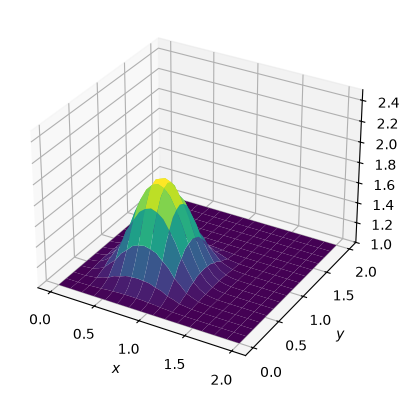

In [9]:
diffuse(10)

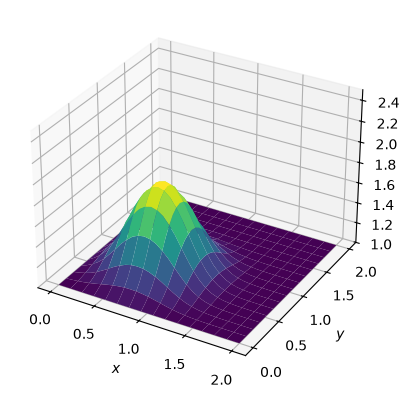

In [10]:
diffuse(14)

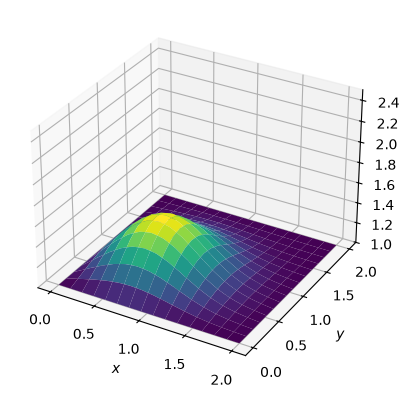

In [11]:
diffuse(50)